<a href="https://colab.research.google.com/github/is6284356-eng/Python-Assignments/blob/main/ICT10_Session7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

In [ ]:
x, y = make_regression(
    n_samples=500,
    n_features= 1,
    noise=1200,
    random_state=42
)

In [ ]:
years_experince = (x*3+7).clip(0,20)

In [ ]:
salary = y+80000

In [ ]:
df = pd.DataFrame({
    'YearsExperince':years_experince.flatten().round(1),
    'Salary' : salary.round(0)
})

In [ ]:
df.to_csv('data.csv',index=False)

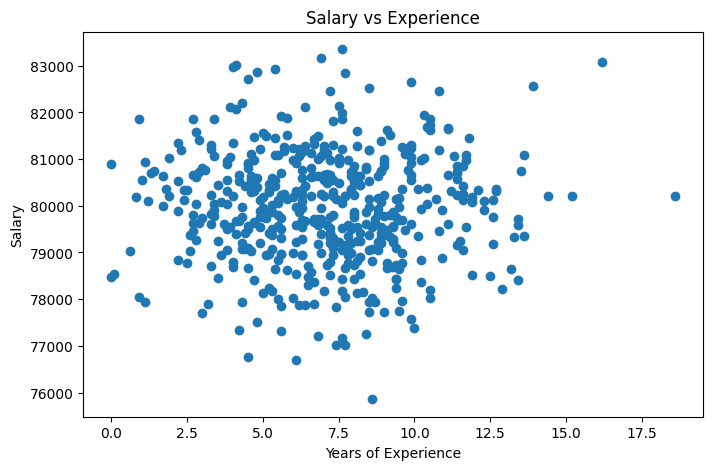

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["YearsExperince"], df["Salary"])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.show()

In [ ]:
# split dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x = df[['YearsExperince']]
y = df['Salary']


In [ ]:
x_train,x_test, y_train,y_test = train_test_split(x,y)


In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
model.coef_

array([-5.06314062])

In [ ]:
model.intercept_

np.float64(80013.04800700526)

In [ ]:
# salary = 8.3 * X  + 79889

predictions = model.predict(x_test)

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results.head()

,Actual,Predicted
304,79736.0,79997.858585
121,77246.0,79970.517626
157,79555.0,79967.986056
194,80311.0,79956.340832
24,79536.0,79973.049196


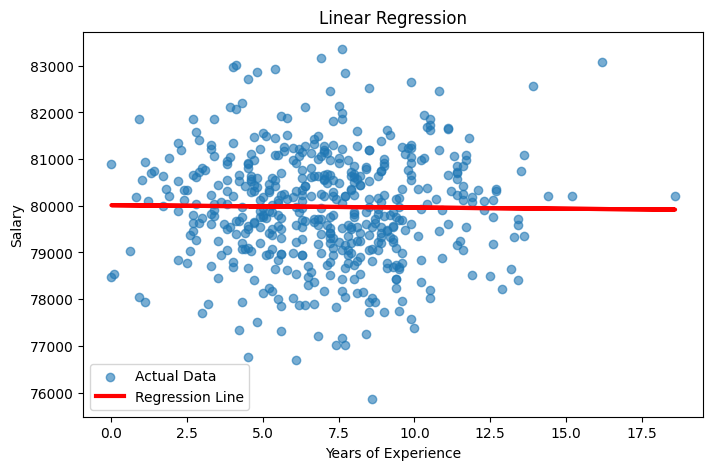

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(x, y, alpha=0.6, label="Actual Data")

plt.plot(
    x,
    model.predict(x),
    color="red",
    linewidth=3,
    label="Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")
plt.legend()

plt.show()

In [ ]:
# prepare data before ml (cleaning/ data quality check)
# split data train test
# train model
# test model
# evaluation matrix

In [ ]:
# calefornia house pricing
from sklearn.datasets import fetch_california_housing

In [ ]:
data  = fetch_california_housing()

In [ ]:
x = data.data
y = data.target

In [ ]:
x = pd.DataFrame(x,columns=data.feature_names)

In [ ]:
x.drop(columns=['Latitude','Longitude'],inplace=True)

In [ ]:
x.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0


In [ ]:
x.duplicated().sum()

np.int64(0)

<Axes: xlabel='MedInc', ylabel='Count'>

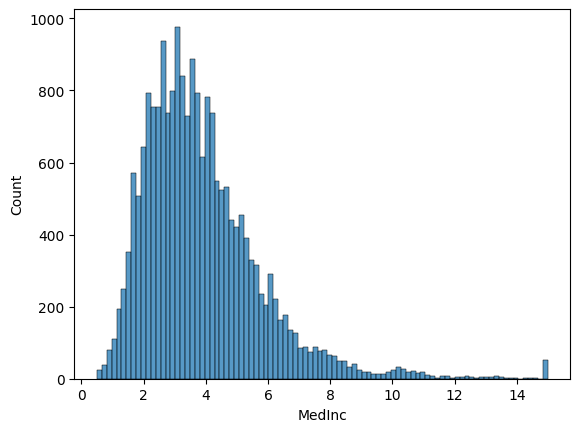

In [ ]:
import seaborn as sns

sns.histplot(x['MedInc'])

In [ ]:
x_train,x_test, y_train, y_test = train_test_split(x,y)

In [ ]:
lr = LinearRegression()

In [ ]:
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
pred = lr.predict(x_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print(mean_absolute_error(y_test, pred))
print(mean_squared_error(y_test, pred))

0.5681099197655977
0.6170954358367183


In [10]:
import pandas as pd
import numpy as np

In [13]:
from google.colab import files

uploaded = files.upload()

Saving simplelinearregression.csv to simplelinearregression.csv


In [14]:
data = pd.read_csv("simplelinearregression.csv")

In [15]:
data.head()

,Age,Premium
0,18,10000
1,22,15000
2,23,18000
3,26,21000
4,28,24000


In [16]:
data.shape

(7, 2)

In [17]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [21]:
model.fit(X_train, y_train)

LinearRegression()

In [22]:
pred = model.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

MAE: 3070.0636942675155
MSE: 9803085.317862792


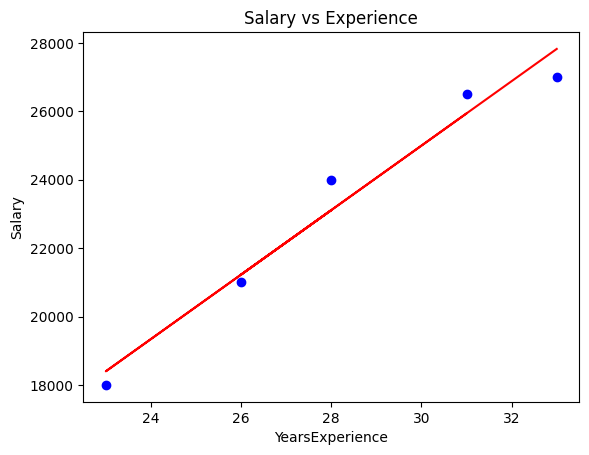

In [24]:
import matplotlib.pyplot as plt

plt.scatter(X_train, y_train, color="blue")
plt.plot(X_train, model.predict(X_train), color="red")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.show()

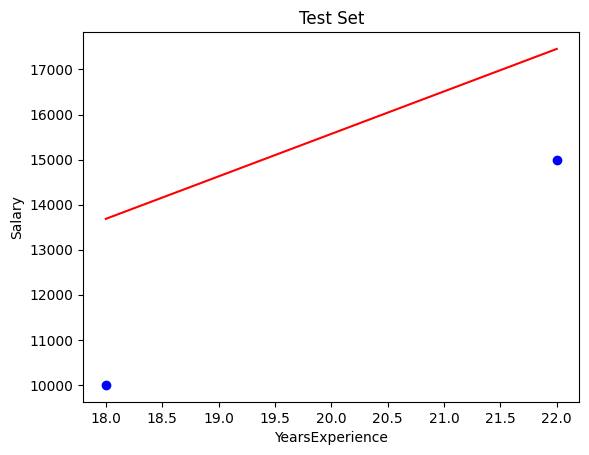

In [25]:
plt.scatter(X_test, y_test, color="blue")
plt.plot(X_test, pred, color="red")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Test Set")
plt.show()